# Prediction Markets — Venue Client Demo

Demonstrates `prediction_markets/venues/*` against the **live public APIs**
of Kalshi, Polymarket.com, Polymarket.us, and predict.fun — no API keys
needed for any of it (predict.fun defaults to its no-key testnet).

Each client exposes the same four methods (see `prediction_markets/venues/base.py`):
- `list_markets()` — markets currently offered
- `get_market(id)` — one market's detail
- `get_price_history(id, ...)` — time series of a market's price
- `get_orderbook(id)` — current bid/ask book

This is the on-demand research layer described in
`.claude/plans/prediction_markets_collector.md`'s intro — not the (separate,
not-yet-built) always-on trade-tape daemon.


In [1]:
%matplotlib inline
import sys
from pathlib import Path

# Run from prediction_markets/, so put the repo root (its parent) on sys.path.
repo_root = Path.cwd().parent if Path.cwd().name == 'prediction_markets' else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option('display.max_colwidth', 60)


## Kalshi
All public, no key required.

In [2]:
from prediction_markets.venues.kalshi import KalshiClient

kalshi = KalshiClient()
kalshi_markets = kalshi._get('/markets', {'limit': 200, 'mve_filter': 'exclude', 'status': 'open'})
kalshi_markets = pd.DataFrame(
    [kalshi._market_from_raw(m).to_row() for m in kalshi_markets['markets']]
)
print(f'{len(kalshi_markets)} open markets (single page)')
kalshi_markets.sort_values('volume', ascending=False).head(10)


200 open markets (single page)


,venue,market_id,title,is_open,is_resolved,last_price,close_time,volume,best_bid,best_ask,league,game_id,event_date,market_type,outcome,line,negated,teams
0,kalshi,KXCONCACAFNL1HBTTS-26SEP25GRNCUB-BTTS,Both teams score in the 1st Half?,True,False,0.0,2026-09-27 21:00:00+00:00,0.0,0.01,0.99,None,None,None,None,None,None,False,{}
1,kalshi,KXCONCACAFNL1HTOTAL-26SEP25GRNCUB-3,Over 2.5 1H goals scored,True,False,0.0,2026-09-27 21:00:00+00:00,0.0,0.00,0.99,None,None,None,None,None,None,False,{}
2,kalshi,KXCONCACAFNL1HTOTAL-26SEP25GRNCUB-2,Over 1.5 1H goals scored,True,False,0.0,2026-09-27 21:00:00+00:00,0.0,0.26,0.99,None,None,None,None,None,None,False,{}
3,kalshi,KXCONCACAFNL1HTOTAL-26SEP25GRNCUB-1,Over 0.5 1H goals scored,True,False,0.0,2026-09-27 21:00:00+00:00,0.0,0.63,0.66,None,None,None,None,None,None,False,{}
4,kalshi,KXCONCACAFNL1HSPREAD-26SEP25GRNCUB-GRN2,Grenada wins by more than 1.5 goals in the 1st Half,True,False,0.0,2026-09-27 21:00:00+00:00,0.0,0.00,0.98,None,None,None,None,None,None,False,{}
5,kalshi,KXCONCACAFNL1HSPREAD-26SEP25GRNCUB-CUB2,Cuba wins by more than 1.5 goals in the 1st Half,True,False,0.0,2026-09-27 21:00:00+00:00,0.0,0.00,0.98,None,None,None,None,None,None,False,{}
6,kalshi,KXCONCACAFNL1H-26SEP25GRNCUB-TIE,Tie 1st Half,True,False,0.0,2026-09-27 21:00:00+00:00,0.0,0.02,0.81,None,None,None,None,None,None,False,{}
7,kalshi,KXCONCACAFNL1H-26SEP25GRNCUB-GRN,Grenada wins 1st Half,True,False,0.0,2026-09-27 21:00:00+00:00,0.0,0.02,0.81,None,None,None,None,None,None,False,{}
8,kalshi,KXCONCACAFNL1H-26SEP25GRNCUB-CUB,Cuba wins 1st Half,True,False,0.0,2026-09-27 21:00:00+00:00,0.0,0.02,0.81,None,None,None,None,None,None,False,{}
9,kalshi,KXPLATINUMH-26SEP2419-T1764.49,Will the platinum close price be above 1764.49 USD/ounce...,True,False,0.0,2026-09-24 23:00:00+00:00,0.0,0.00,0.99,None,None,None,None,None,None,False,{}


In [3]:
# Pick the most liquid market on this page for the history/orderbook demo
kalshi_ticker = kalshi_markets.sort_values('volume', ascending=False).iloc[0]['market_id']
print('Using ticker:', kalshi_ticker)

kalshi.get_market(kalshi_ticker)


Using ticker: KXCONCACAFNL1HBTTS-26SEP25GRNCUB-BTTS


,venue,market_id,title,is_open,is_resolved,last_price,close_time,volume,best_bid,best_ask,league,game_id,event_date,market_type,outcome,line,negated,teams
0,kalshi,KXCONCACAFNL1HBTTS-26SEP25GRNCUB-BTTS,Both teams score in the 1st Half?,True,False,0.0,2026-09-27 21:00:00+00:00,0.0,0.01,0.99,None,None,None,None,None,None,False,{}


In [4]:
kalshi_hist = kalshi.get_price_history(kalshi_ticker, resolution='1m')
print(f'{len(kalshi_hist)} price points')
kalshi_hist.tail()


0 price points


,venue,market_id,ts,price


In [5]:
if not kalshi_hist.empty:
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(kalshi_hist['ts'], kalshi_hist['price'], marker='o', markersize=3)
    ax.set_title(f'Kalshi — {kalshi_ticker} price history')
    ax.set_ylabel('price ($ / contract)')
    fig.autofmt_xdate()
    plt.show()
else:
    print('No trades yet in the lookback window for this market/resolution.')


No trades yet in the lookback window for this market/resolution.


In [6]:
kalshi_book = kalshi.get_orderbook(kalshi_ticker)
print('best bid / best ask:', kalshi_book.best_bid, '/', kalshi_book.best_ask)
kalshi_book.to_dataframe()


best bid / best ask: 0.01 / 0.99


,venue,market_id,ts,side,price,size
0,kalshi,KXCONCACAFNL1HBTTS-26SEP25GRNCUB-BTTS,2026-09-24 21:09:02.460616+00:00,bid,0.01,676.0
1,kalshi,KXCONCACAFNL1HBTTS-26SEP25GRNCUB-BTTS,2026-09-24 21:09:02.460616+00:00,ask,0.99,690.0


### Depth chart
`plot_order_book()` renders the classic L2 depth view (cumulative size vs. price, green bid area building up to the left of the spread, red ask area to the right) straight from an `OrderBook` -- no data wrangling needed.

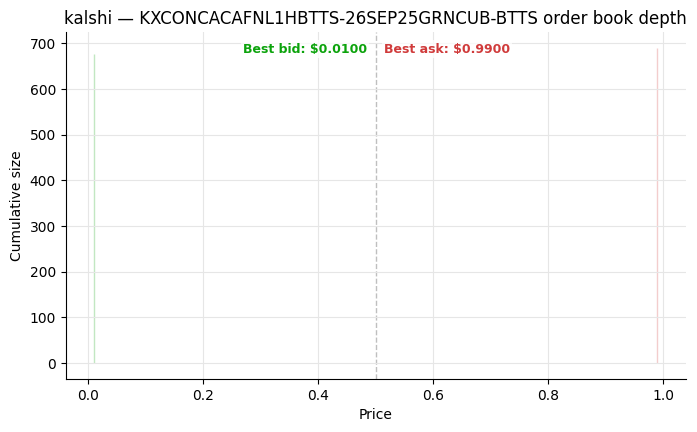

In [7]:
from prediction_markets.plotting import plot_order_book

plot_order_book(kalshi_book)
plt.show()


## Polymarket.com
All public, no key required. Two token ids per market (one per outcome) — `get_price_history`/`get_orderbook` default to outcome index 0 ("Yes").

In [8]:
from prediction_markets.venues.polymarket_com import PolymarketComClient

poly_com = PolymarketComClient()
poly_com_markets = poly_com._get_gamma('/markets', {'limit': 20, 'active': 'true', 'closed': 'false',
                                                     'order': 'volume24hr', 'ascending': 'false'})
poly_com_markets = pd.DataFrame([poly_com._market_from_raw(m).to_row() for m in poly_com_markets])
poly_com_markets.head(10)


,venue,market_id,title,is_open,is_resolved,last_price,close_time,volume,best_bid,best_ask,league,game_id,event_date,market_type,outcome,line,negated,teams
0,polymarket_com,unl-nor-den-2026-09-24-nor,Will Norway win on 2026-09-24?,True,False,0.9995,2026-09-24 18:45:00+00:00,1.350951e+07,None,None,None,None,None,None,None,None,False,{}
1,polymarket_com,nfl-atl-gb-2026-09-25-spread-home-4pt5,Spread: Packers (-4.5),True,False,0.5150,2026-09-25 00:15:00+00:00,1.573871e+06,None,None,None,None,None,None,None,None,False,{}
2,polymarket_com,unl-nld-ger-2026-09-24-ger,Will Germany win on 2026-09-24?,True,False,0.0005,2026-09-24 18:45:00+00:00,6.945642e+05,None,None,None,None,None,None,None,None,False,{}
3,polymarket_com,unl-nld-ger-2026-09-24-nld,Will Netherlands win on 2026-09-24?,True,False,0.0005,2026-09-24 18:45:00+00:00,5.449025e+05,None,None,None,None,None,None,None,None,False,{}
4,polymarket_com,will-the-fed-decrease-interest-rates-by-50-bps-after-the...,Will the Fed decrease interest rates by 50+ bps after th...,True,False,0.0025,2026-10-29 03:59:00+00:00,1.924647e+06,None,None,None,None,None,None,None,None,False,{}
5,polymarket_com,unl-prt-wal-2026-09-24-wal,Will Wales win on 2026-09-24?,True,False,0.0005,2026-09-24 18:45:00+00:00,4.721393e+05,None,None,None,None,None,None,None,None,False,{}
6,polymarket_com,will-the-fed-increase-interest-rates-by-25-bps-after-the...,Will the Fed increase interest rates by 25 bps after the...,True,False,0.6650,2026-10-29 03:59:00+00:00,3.397900e+06,None,None,None,None,None,None,None,None,False,{}
7,polymarket_com,will-shakhtar-donetsk-win-the-2026-27-uefa-champions-lea...,Will Shakhtar Donetsk win the 2026-27 UEFA Champions Lea...,True,False,0.0015,2027-05-30 23:59:00+00:00,2.187350e+07,None,None,None,None,None,None,None,None,False,{}
8,polymarket_com,unl-prt-wal-2026-09-24-prt,Will Portugal win on 2026-09-24?,True,False,0.9995,2026-09-24 18:45:00+00:00,4.300250e+05,None,None,None,None,None,None,None,None,False,{}
9,polymarket_com,will-sarah-huckabee-sanders-win-the-2028-republican-pres...,Will Sarah Huckabee Sanders win the 2028 Republican pres...,True,False,0.0005,2028-11-07 00:00:00+00:00,3.550587e+07,None,None,None,None,None,None,None,None,False,{}


In [9]:
poly_com_slug = poly_com_markets.iloc[0]['market_id']
print('Using slug:', poly_com_slug)

poly_com.get_market(poly_com_slug)


Using slug: unl-nor-den-2026-09-24-nor


,venue,market_id,title,is_open,is_resolved,last_price,close_time,volume,best_bid,best_ask,league,game_id,event_date,market_type,outcome,line,negated,teams
0,polymarket_com,unl-nor-den-2026-09-24-nor,Will Norway win on 2026-09-24?,True,False,0.9995,2026-09-24 18:45:00+00:00,1.350396e+07,None,None,None,None,None,None,None,None,False,{}


324 price points


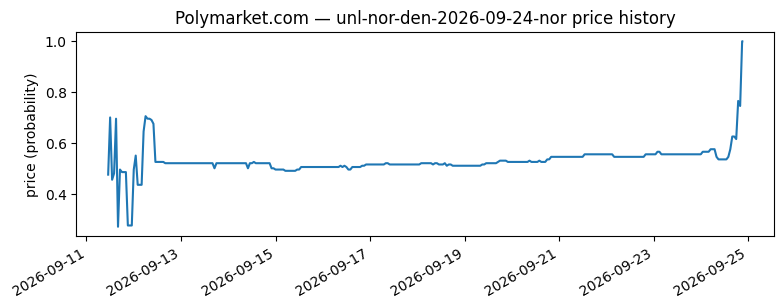

In [10]:
poly_com_hist = poly_com.get_price_history(poly_com_slug, resolution='1h')
print(f'{len(poly_com_hist)} price points')

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(poly_com_hist['ts'], poly_com_hist['price'])
ax.set_title(f'Polymarket.com — {poly_com_slug} price history')
ax.set_ylabel('price (probability)')
fig.autofmt_xdate()
plt.show()


best bid / best ask: 0.999 / None


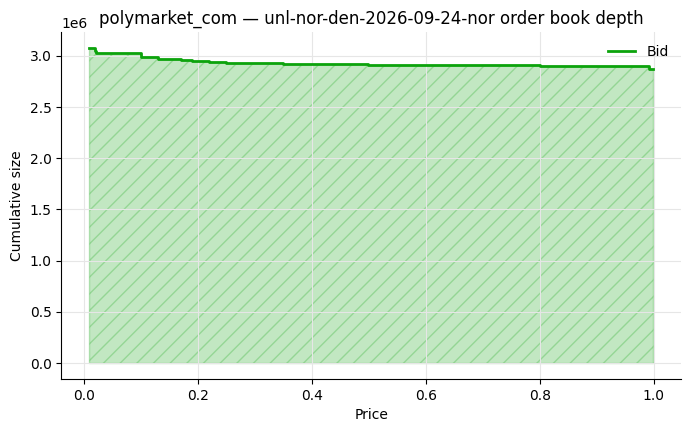

In [11]:
poly_com_book = poly_com.get_orderbook(poly_com_slug)
print('best bid / best ask:', poly_com_book.best_bid, '/', poly_com_book.best_ask)

plot_order_book(poly_com_book)
plt.show()


## Polymarket.us
CFTC-regulated, separate stack from Polymarket.com — different markets (mostly sports), different ids (slugs), no shared infra. All reads here are public, no key. `GET /v1/markets` defaults to **oldest-first**, so a small page is mostly closed/settled markets — fine for demoing `get_price_history`/`get_orderbook` parsing either way.

In [12]:
from prediction_markets.venues.polymarket_us import PolymarketUSClient

poly_us = PolymarketUSClient()
poly_us_page = poly_us._get('/v1/markets', {'limit': 20})['markets']
poly_us_markets = pd.DataFrame([poly_us._market_from_raw(m).to_row() for m in poly_us_page])
poly_us_markets.head(10)


,venue,market_id,title,is_open,is_resolved,last_price,close_time,volume,best_bid,best_ask,league,game_id,event_date,market_type,outcome,line,negated,teams
0,polymarket_us,aec-nfl-lac-ten-2025-11-02,Los Angeles vs. Tennessee,False,True,None,2025-11-03 18:00:00+00:00,None,None,None,None,None,None,None,None,None,False,{}
1,polymarket_us,aec-nfl-car-gb-2025-11-02,Carolina vs. Green Bay,False,True,None,2025-11-03 18:00:00+00:00,None,None,None,None,None,None,None,None,None,False,{}
2,polymarket_us,aec-nfl-min-det-2025-11-02,Minnesota vs. Detroit,False,True,None,2025-11-03 18:00:00+00:00,None,None,None,None,None,None,None,None,None,False,{}
3,polymarket_us,aec-nfl-atl-ne-2025-11-02,Atlanta vs. New England,False,True,None,2025-11-03 18:00:00+00:00,None,None,None,None,None,None,None,None,None,False,{}
4,polymarket_us,aec-nfl-no-lar-2025-11-02,New Orleans vs. Los Angeles,False,True,None,2025-11-03 21:05:00+00:00,None,None,None,None,None,None,None,None,None,False,{}
5,polymarket_us,aec-nfl-bal-mia-2025-10-30,Baltimore vs. Miami,False,True,None,2025-11-01 00:15:00+00:00,None,None,None,None,None,None,None,None,None,False,{}
6,polymarket_us,aec-nfl-chi-cin-2025-11-02,Chicago vs. Cincinnati,False,True,None,2025-11-03 18:00:00+00:00,None,None,None,None,None,None,None,None,None,False,{}
7,polymarket_us,aec-nfl-sf-nyg-2025-11-02,San Francisco vs. New York,False,True,None,2025-11-03 18:00:00+00:00,None,None,None,None,None,None,None,None,None,False,{}
8,polymarket_us,aec-nfl-den-hou-2025-11-02,Denver vs. Houston,False,True,None,2025-11-03 18:00:00+00:00,None,None,None,None,None,None,None,None,None,False,{}
9,polymarket_us,aec-nfl-ind-pit-2025-11-02,Indianapolis vs. Pittsburgh,False,True,None,2025-11-03 18:00:00+00:00,None,None,None,None,None,None,None,None,None,False,{}


In [13]:
poly_us_slug = poly_us_markets.iloc[0]['market_id']
print('Using slug:', poly_us_slug)

poly_us.get_market(poly_us_slug)


Using slug: aec-nfl-lac-ten-2025-11-02


,venue,market_id,title,is_open,is_resolved,last_price,close_time,volume,best_bid,best_ask,league,game_id,event_date,market_type,outcome,line,negated,teams
0,polymarket_us,aec-nfl-lac-ten-2025-11-02,Los Angeles vs. Tennessee,False,True,None,2025-11-03 18:00:00+00:00,None,None,None,None,None,None,None,None,None,False,{}


In [14]:
poly_us_hist = poly_us.get_price_history(poly_us_slug, resolution='1d')
print(f'{len(poly_us_hist)} price points')
poly_us_hist


5 price points


,venue,market_id,ts,price
0,polymarket_us,aec-nfl-lac-ten-2025-11-02,2025-10-29 00:00:00+00:00,0.500
1,polymarket_us,aec-nfl-lac-ten-2025-11-02,2025-10-30 00:00:00+00:00,0.855
2,polymarket_us,aec-nfl-lac-ten-2025-11-02,2025-10-31 00:00:00+00:00,0.860
3,polymarket_us,aec-nfl-lac-ten-2025-11-02,2025-11-01 00:00:00+00:00,0.860
4,polymarket_us,aec-nfl-lac-ten-2025-11-02,2025-11-02 00:00:00+00:00,0.999


In [15]:
poly_us_book = poly_us.get_orderbook(poly_us_slug)
print('best bid / best ask:', poly_us_book.best_bid, '/', poly_us_book.best_ask)
poly_us_book.to_dataframe()


best bid / best ask: None / None


,venue,market_id,ts,side,price,size


## predict.fun
Onchain, BNB Chain. Uses the **no-key testnet** by default (`PredictFunClient()`); mainnet reads need `PREDICT_FUN_API_KEY` in `.env` (`PredictFunClient(env='mainnet')`). `get_price_history` isn't implemented yet — its `/timeseries` endpoint needs an undocumented `metric` parameter (see the module docstring in `prediction_markets/venues/predict_fun.py`).

Unlike the other three venues, predict.fun's `/v1/markets` has **no server-side open/status filter** and testnet alone has 2,000+ markets, so `list_markets()` pages through everything by default (bounded by `max_pages`, default 50 pages ≈ 1,000 markets). For this demo we cap it small to stay fast.

In [16]:
from prediction_markets.venues.predict_fun import PredictFunClient

predict_fun = PredictFunClient()  # testnet, no key
pf_markets = predict_fun.list_markets(open_only=True, max_pages=3)  # ~60 markets, keeps the demo fast
print(f'{len(pf_markets)} open markets (first few pages only)')
pf_markets.head(10)


44 open markets (first few pages only)


,venue,market_id,title,is_open,is_resolved,last_price,close_time,volume,best_bid,best_ask,league,game_id,event_date,market_type,outcome,line,negated,teams
0,predict_fun,437,David Malpass,True,False,0.350,None,None,None,None,None,None,None,None,None,None,False,{}
1,predict_fun,434,Christopher Waller,True,False,0.635,None,None,None,None,None,None,None,None,None,None,False,{}
2,predict_fun,433,Kevin Hassett,True,False,0.285,None,None,None,None,None,None,None,None,None,None,False,{}
3,predict_fun,435,Bill Pulte,True,False,0.435,None,None,None,None,None,None,None,None,None,None,False,{}
4,predict_fun,432,Kevin Warsh,True,False,0.660,None,None,None,None,None,None,None,None,None,None,False,{}
5,predict_fun,436,Judy Shelton,True,False,0.565,None,None,None,None,None,None,None,None,None,None,False,{}
6,predict_fun,438,Howard Lutnick,True,False,0.655,None,None,None,None,None,None,None,None,None,None,False,{}
7,predict_fun,439,Individual T,True,False,0.090,None,None,None,None,None,None,None,None,None,None,False,{}
8,predict_fun,440,Arthur Laffer,True,False,0.460,None,None,None,None,None,None,None,None,None,None,False,{}
9,predict_fun,441,Larry Kudlow,True,False,0.295,None,None,None,None,None,None,None,None,None,None,False,{}


In [17]:
pf_market_id = pf_markets.iloc[0]['market_id']
print('Using market id:', pf_market_id)

predict_fun.get_market(pf_market_id)


Using market id: 437


,venue,market_id,title,is_open,is_resolved,last_price,close_time,volume,best_bid,best_ask,league,game_id,event_date,market_type,outcome,line,negated,teams
0,predict_fun,437,David Malpass,True,False,0.35,None,None,None,None,None,None,None,None,None,None,False,{}


In [18]:
pf_book = predict_fun.get_orderbook(pf_market_id)
print('best bid / best ask:', pf_book.best_bid, '/', pf_book.best_ask)
pf_book.to_dataframe()


best bid / best ask: 0.33 / 0.37


,venue,market_id,ts,side,price,size
0,predict_fun,437,2026-09-24 19:03:06.999000+00:00,bid,0.33,123197.6925
1,predict_fun,437,2026-09-24 19:03:06.999000+00:00,bid,0.17,6.0764
2,predict_fun,437,2026-09-24 19:03:06.999000+00:00,bid,0.10,61.5430
3,predict_fun,437,2026-09-24 19:03:06.999000+00:00,bid,0.08,52.5770
4,predict_fun,437,2026-09-24 19:03:06.999000+00:00,bid,0.03,95537.0000
5,predict_fun,437,2026-09-24 19:03:06.999000+00:00,ask,0.37,796428.2433
6,predict_fun,437,2026-09-24 19:03:06.999000+00:00,ask,0.45,7.5211
7,predict_fun,437,2026-09-24 19:03:06.999000+00:00,ask,0.84,45.5410


In [19]:
# get_price_history is a documented gap, not a silent failure:
try:
    predict_fun.get_price_history(pf_market_id)
except NotImplementedError as e:
    print('Expected gap:', e)


Expected gap: predict.fun's /v1/markets/{id}/timeseries requires a `metric` query parameter whose valid enum value could not be determined (see this module's docstring) -- fix _RESOLUTION_INTERVAL and this method once the real parameter is known.


## Cross-venue matching: Kalshi ↔ Polymarket.us

`prediction_markets.matching.match_markets(left, right)` takes two `list_markets()` DataFrames and returns every pair of markets that settle on the same (or exactly opposite) outcome of the same game. It's a standalone, pure function, so it runs on cached frames too. Each venue client does its own ticker/slug parsing into normalized proposition columns on `Market`:

| column | meaning |
|---|---|
| `league`, `game_id`, `event_date` | which game (`game_id` is venue-native and shared by every market on the game) |
| `market_type` | `winner` / `spread` / `total` (full game only; futures, props, halves and quarters stay `None`) |
| `outcome`, `line` | proposition: *outcome wins*, *outcome wins by > line*, or *total > line* |
| `negated` | YES/long pays when the proposition is **false** (e.g. .us "ATL +3.5" = NOT "GB wins by > 3.5") |

Matching has two steps:
1. **Games** are paired within each (league, date) by team-name similarity. Codes only line up for the NFL; college football and UFC need names (`librty` ↔ `LIB`, `rauros` ↔ `ROS`).
2. **Markets** within a matched game are then joined on the proposition. `orientation` is `same` or `inverted`, and the right venue's price and bid/ask are restated in the left market's terms (`*_aligned`).

Fetching only the sports series/market types keeps this to a few minutes: Kalshi ~6k markets (vs 130k+ unfiltered), Polymarket.us ~23k.

In [20]:
import time

from prediction_markets.matching import match_markets
from prediction_markets.venues.kalshi import SPORTS_SERIES
from prediction_markets.venues.polymarket_us import SPORTS_MARKET_TYPES

t0 = time.time()
kalshi_sports = kalshi.list_markets(series_ticker=SPORTS_SERIES)
print(f'Kalshi: {len(kalshi_sports):,} open sports markets ({time.time() - t0:.0f}s)')

t0 = time.time()
poly_us_sports = poly_us.list_markets(market_types=SPORTS_MARKET_TYPES)
print(f'Polymarket.us: {len(poly_us_sports):,} open moneyline/spread/total markets ({time.time() - t0:.0f}s), '
      f'{poly_us_sports["market_type"].notna().sum():,} of them full-game winner/spread/total')

Kalshi: 6,413 open sports markets (26s)


Polymarket.us: 22,842 open moneyline/spread/total markets (154s), 7,958 of them full-game winner/spread/total


In [21]:
matches = match_markets(kalshi_sports, poly_us_sports)
matches['game'] = matches['left_market_id'].str.split('-').str[1]   # Kalshi game code, e.g. 26SEP24ATLGB
print(f'{len(matches):,} matched market pairs across {matches["game"].nunique():,} games')
matches.pivot_table(index='league', columns=['market_type', 'orientation'], values='left_market_id',
                    aggfunc='count', fill_value=0)

3,587 matched market pairs across 372 games


market_type   spread      total   winner     
orientation inverted same  same inverted same
league                                       
cfb             1042  765   304      233  233
mlb               26   26    36       52   52
nfl              206  208   212       32   32
nhl                0    0     0       27   27
ufc                0    0     0       24   24
wnba               2    5     9        5    5

### One game, every matched bet
Each Kalshi winner market pairs with the single .us winner market: `same` for the team .us is long, `inverted` for the other. Each Kalshi spread "X wins by > L" pairs with both .us spreads on that line (`X -L` is `same`, `Y +L` is `inverted`).

In [22]:
show_cols = ['proposition', 'orientation', 'left_market_id', 'right_market_id',
             'left_bid', 'left_ask', 'right_bid_aligned', 'right_ask_aligned', 'arb_edge']
nfl_game = matches.loc[matches['league'] == 'nfl', 'game'].iloc[0]
matches[matches['game'] == nfl_game].sort_values(['market_type', 'line'])[show_cols].head(20)

,proposition,orientation,left_market_id,right_market_id,left_bid,left_ask,right_bid_aligned,right_ask_aligned,arb_edge
2687,GB wins by > 1.5,inverted,KXNFLSPREAD-26SEP24ATLGB-GB2,asc-nfl-atl-gb-2026-09-24-pos-1pt5,0.65,0.66,0.655,0.660,-0.005
2700,ATL wins by > 1.5,same,KXNFLSPREAD-26SEP24ATLGB-ATL2,asc-nfl-atl-gb-2026-09-24-neg-1pt5,0.29,0.30,0.290,0.295,-0.005
2683,GB wins by > 2.5,inverted,KXNFLSPREAD-26SEP24ATLGB-GB3,asc-nfl-atl-gb-2026-09-24-pos-2pt5,0.63,0.64,0.630,0.635,-0.005
2699,ATL wins by > 2.5,same,KXNFLSPREAD-26SEP24ATLGB-ATL3,asc-nfl-atl-gb-2026-09-24-neg-2pt5,0.27,0.28,0.270,0.275,-0.005
2682,GB wins by > 3.5,inverted,KXNFLSPREAD-26SEP24ATLGB-GB4,asc-nfl-atl-gb-2026-09-24-pos-3pt5,0.54,0.55,0.540,0.545,-0.005
2698,ATL wins by > 3.5,same,KXNFLSPREAD-26SEP24ATLGB-ATL4,asc-nfl-atl-gb-2026-09-24-neg-3pt5,0.21,0.22,0.210,0.215,-0.005
2681,GB wins by > 4.5,inverted,KXNFLSPREAD-26SEP24ATLGB-GB5,asc-nfl-atl-gb-2026-09-24-pos-4pt5,0.52,0.53,0.520,0.525,-0.005
2697,ATL wins by > 4.5,same,KXNFLSPREAD-26SEP24ATLGB-ATL5,asc-nfl-atl-gb-2026-09-24-neg-4pt5,0.19,0.20,0.195,0.200,-0.005
2680,GB wins by > 5.5,inverted,KXNFLSPREAD-26SEP24ATLGB-GB6,asc-nfl-atl-gb-2026-09-24-pos-5pt5,0.48,0.49,0.480,0.485,-0.005
2696,ATL wins by > 5.5,same,KXNFLSPREAD-26SEP24ATLGB-ATL6,asc-nfl-atl-gb-2026-09-24-neg-5pt5,0.18,0.19,0.180,0.185,-0.005


### Sanity check: do matched pairs agree on price?
If the matching and orientation are right, a matched pair should quote the same probability on both venues. Below, each dot is a pair where both books are two-sided and tight (spread ≤ 10¢): Kalshi mid on x, the aligned Polymarket.us mid on y. A wrong orientation would put a dot near the *other* diagonal (y = 1 − x).

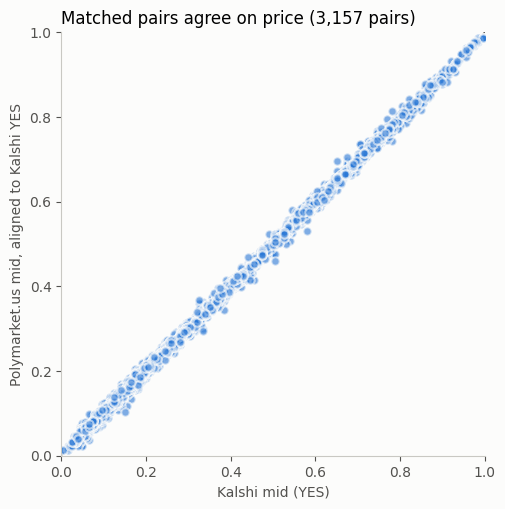

median |mid gap|: 0.0050   95th pct: 0.0175


In [23]:
SERIES_1, MUTED, SURFACE = '#2a78d6', '#52514e', '#fcfcfb'   # dataviz reference palette

tight = matches.dropna(subset=['left_bid', 'left_ask', 'right_bid_aligned', 'right_ask_aligned'])
tight = tight[(tight['left_ask'] - tight['left_bid'] <= 0.10)
              & (tight['right_ask_aligned'] - tight['right_bid_aligned'] <= 0.10)]
left_mid = (tight['left_bid'] + tight['left_ask']) / 2
right_mid = (tight['right_bid_aligned'] + tight['right_ask_aligned']) / 2

fig, ax = plt.subplots(figsize=(5.5, 5.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.plot([0, 1], [0, 1], color=MUTED, linewidth=1, linestyle='--', zorder=1)
ax.scatter(left_mid, right_mid, s=36, color=SERIES_1, edgecolor=SURFACE, linewidth=1.5, alpha=0.6, zorder=2)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
ax.set_xlabel('Kalshi mid (YES)', color=MUTED)
ax.set_ylabel('Polymarket.us mid, aligned to Kalshi YES', color=MUTED)
ax.set_title(f'Matched pairs agree on price ({len(tight):,} pairs)', loc='left')
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
for side in ('left', 'bottom'):
    ax.spines[side].set_color('#c9c8c3')
ax.tick_params(colors=MUTED)
plt.show()
print(f'median |mid gap|: {(right_mid - left_mid).abs().median():.4f}   '
      f'95th pct: {(right_mid - left_mid).abs().quantile(0.95):.4f}')

### Crossed books
`arb_edge` is the gross profit per $1 contract from buying the proposition on one venue at its ask and the complement on the other at its ask. It equals the best aligned bid minus the other venue's ask, and it's positive only when the two books cross. It **ignores fees** (Kalshi charges up to ~1.75¢/contract near 50¢), **depth**, and **settlement-rule differences**: ties, draws, overtime and postponements. Winner markets paired as `inverted` assume the game can't end tied; .us settles NFL ties and UFC draws at $0.50. Top-of-book quotes come from the list payloads, so re-check them against live books before acting on any row.

In [24]:
crossed = matches[matches['arb_edge'] > 0].sort_values('arb_edge', ascending=False)
print(f'{len(crossed)} of {len(matches):,} pairs have crossed top-of-book quotes (before fees)')
crossed[['league', 'event_date', *show_cols]].head(15)

174 of 3,587 pairs have crossed top-of-book quotes (before fees)


,league,event_date,proposition,orientation,left_market_id,right_market_id,left_bid,left_ask,right_bid_aligned,right_ask_aligned,arb_edge
1044,cfb,2026-09-26,TOL wins by > 14.5,inverted,KXNCAAFSPREAD-26SEP26SDSUTOL-TOL15,asc-cfb-sdst-toledo-2026-09-26-pos-14pt5,0.17,0.18,0.200,0.210,0.020
1333,cfb,2026-09-26,MSU wins by > 7.5,inverted,KXNCAAFSPREAD-26SEP26NEBMSU-MSU8,asc-cfb-nebr-mst-2026-09-26-pos-7pt5,0.14,0.17,0.115,0.120,0.020
2163,cfb,2026-09-26,total > 47.5,same,KXNCAAFTOTAL-26SEP26OKSTWVU-48,tsc-cfb-okst-wvir-2026-09-26-total-47pt5,0.77,0.79,0.810,0.820,0.020
2627,mlb,2026-09-26,PHI wins,inverted,KXMLBGAME-26SEP261915TBPHI-PHI,aec-mlb-tb-phi-2026-09-26,0.50,0.51,0.475,0.480,0.020
1615,cfb,2026-09-26,total > 47.5,same,KXNCAAFTOTAL-26SEP26SHSUTTU-48,tsc-cfb-smho-txtech-2026-09-26-total-47pt5,0.70,0.71,0.730,0.740,0.020
40,cfb,2026-09-25,CLEM wins by > 10.5,same,KXNCAAFSPREAD-26SEP25CLEMCAL-CLEM11,asc-cfb-clmsn-cah-2026-09-25-neg-10pt5,0.23,0.24,0.255,0.260,0.015
801,cfb,2026-09-26,CIT wins,inverted,KXNCAAFGAME-26SEP26CHATCIT-CIT,aec-cfb-chat-cita-2026-09-26,0.20,0.21,0.225,0.230,0.015
995,cfb,2026-09-26,DRKE wins by > 10.5,same,KXNCAAFSPREAD-26SEP26DRKEDAV-DRKE11,asc-cfb-drake-dav-2026-09-26-neg-10pt5,0.52,0.54,0.495,0.505,0.015
1725,cfb,2026-09-26,UNLV wins by > 10.5,same,KXNCAAFSPREAD-26SEP26UNLVAKR-UNLV11,asc-cfb-unlv-akron-2026-09-26-neg-10pt5,0.53,0.54,0.555,0.560,0.015
751,cfb,2026-09-26,BUFF wins by > 30.5,inverted,KXNCAAFSPREAD-26SEP26RMUBUFF-BUFF31,asc-cfb-robms-buf-2026-09-26-pos-30pt5,0.43,0.48,0.410,0.420,0.010


In [25]:
# Re-check the top candidate against both live order books (sizes included).
if not crossed.empty:
    top = crossed.iloc[0]
    k_book = kalshi.get_orderbook(top['left_market_id'])
    u_book = poly_us.get_orderbook(top['right_market_id'])
    print(f"{top['proposition']}  ({top['orientation']})")
    print(f"  Kalshi   {top['left_market_id']:<45} bid {k_book.best_bid} x {k_book.bids[0].size if k_book.bids else 0:,.0f}"
          f"   ask {k_book.best_ask} x {k_book.asks[0].size if k_book.asks else 0:,.0f}")
    print(f"  Poly.us  {top['right_market_id']:<45} bid {u_book.best_bid} x {u_book.bids[0].size if u_book.bids else 0:,.0f}"
          f"   ask {u_book.best_ask} x {u_book.asks[0].size if u_book.asks else 0:,.0f}   (long side, not aligned)")

TOL wins by > 14.5  (inverted)
  Kalshi   KXNCAAFSPREAD-26SEP26SDSUTOL-TOL15            bid 0.17 x 202   ask 0.18 x 1
  Poly.us  asc-cfb-sdst-toledo-2026-09-26-pos-14pt5      bid 0.79 x 52   ask 0.8 x 2   (long side, not aligned)


## Summary

All four clients pull live public market data with **zero credentials**
(predict.fun mainnet is the one exception, and it's optional). Everything
above returns plain `pandas.DataFrame`s (or an `OrderBook` with a
`.to_dataframe()` and a `plot_order_book()` depth chart), so this plugs
directly into research notebooks or a backtest without any glue code.

`match_markets()` pairs equivalent Kalshi ↔ Polymarket.us game bets (winner/spread/total) with orientation and aligned quotes, the starting point for cross-venue arbitrage.

Known gaps to close before relying on this further:
- Matching covers full-game winner/spread/total only (no halves/quarters/props/futures) and doesn't compare settlement rules; MLB doubleheaders on the same date could pair the wrong game
- predict.fun `get_price_history` (needs the real `/timeseries` `metric` param)
- No persistence/state here by design — see
  `.claude/plans/prediction_markets_collector.md` for the separate always-on
  trade-tape collector these same clients are meant to plug into later.
